In [1]:
import numpy as np
import struct
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_local_mnist_img(filename):
    with open(filename, 'rb') as f:
        #Read header: magic number(4 bytes), num images(4 bytes), num rows(4 bytes), num cols(4 bytes)
        magic, num_images, rows, cols =struct.unpack('>IIII', f.read(16))
        '''f.read(16): tells Python to go to the file and scoop up exactly the next
        16 bytes of raw binary data. At this point, Python holds a raw,
        unreadable byte string that looks like this to your computer'''
        '''struct.unpack('>IIII', ...): takes that raw 16-byte chunk we just 
        read and parses ("unpacks") it into a standard Python tuple of integers
        or characters based on a specific blueprint you provide.'''  
        '''By putting > at the beginning, you are telling your modern computer: "Hey CPU,
        I know you usually read bytes right-to-left, but this file was written left-to-right.
        Swap your reading direction for this step so the numbers don't get scrambled backward!"'''
        '''First I: Take bytes 0 to 3, treat them as a Big-Endian integer, and assign it to magic.
        Second I: Take bytes 4 to 7, convert them, and assign it to num_images.
        Third I: Take bytes 8 to 11, convert them, and assign it to rows.
        Fourth I: Take bytes 12 to 15, convert them, and assign it to cols.''' 
        #read remaining raw data and convert to numpy array
        buffer=f.read()
        data=np.frombuffer(buffer, dtype=np.uint8)
        data=data.reshape(num_images, rows*cols)/255.0
        return data
    
def load_local_mnist_labels(filename):
    with open(filename, 'rb') as f:
    # Read header: magic number (4 bytes), num items (4 bytes)
        magic, num_items = struct.unpack('>II', f.read(8))      
        # Read the single-byte labels directly into a NumPy array
        buffer = f.read()
        return np.frombuffer(buffer, dtype=np.uint8)
'''Every image can be represented as a 3-D matrix. If we have a color image of size 28×28,
 we have 28 x 28 x 3 numbers to represent that image(3 for the RGB(Red-Green-Blue) channel).'''

'Every image can be represented as a 3-D matrix. If we have a color image of size 28×28,\n we have 28 x 28 x 3 numbers to represent that image(3 for the RGB(Red-Green-Blue) channel).'

In [3]:
X_train = load_local_mnist_img('archive/train-images.idx3-ubyte')
y_train = load_local_mnist_labels('archive/train-labels.idx1-ubyte')
#X_train is a matrix with 60,000 rows and 784 columns. Each row corresponds to a single image,
#and each column corresponds to a pixel value (normalized between 0 and 1).
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (60000, 784)
y_train shape: (60000,)


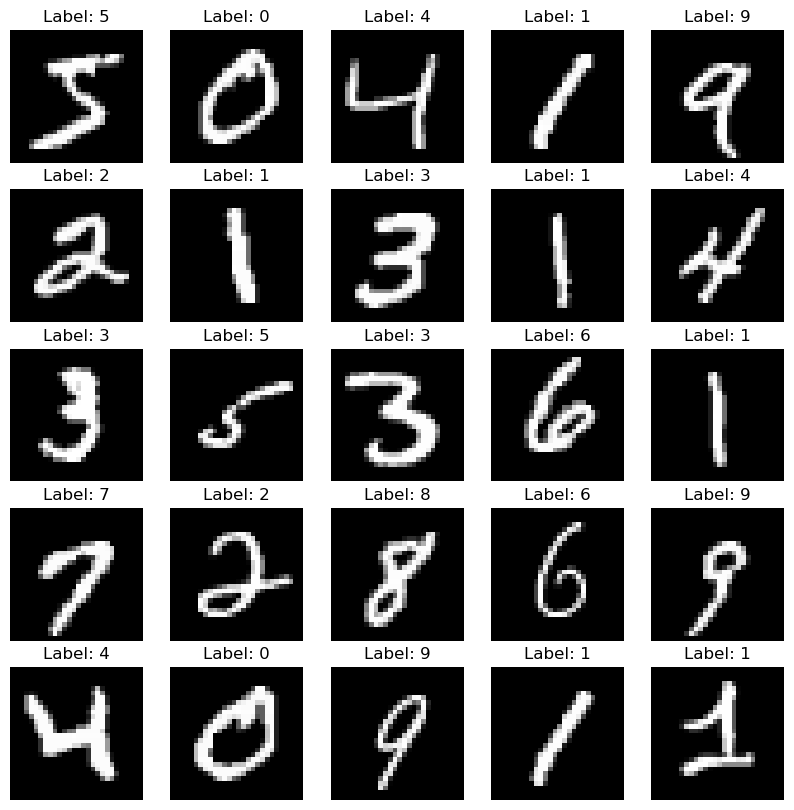

In [4]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

To map 784 pixel inputs to 10 possible digit classes (0 through 9), you need a Weight matrix ($W$) and a Bias vector ($b$).

In [5]:
num_features = 784
num_classes = 10
W = np.random.randn(num_features, num_classes) * 0.01
b = np.zeros((1, num_classes))
print("Weights matrix shape:", W.shape)
print("Bias vector shape:", b.shape)

Weights matrix shape: (784, 10)
Bias vector shape: (1, 10)


**One hot Encoding**

In [6]:
y_train.shape[0]

60000

In [7]:
def one_hot_encode(y, num_classes=10):
    one_hot=np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y]=1
     # Putting 1 for column where the label is,
    # Using multidimensional indexing.
    return one_hot

Y_train_encoded = one_hot_encode(y_train)
print("Encoded labels shape:", Y_train_encoded.shape)

Encoded labels shape: (60000, 10)


In [8]:
X_test = load_local_mnist_img('archive/t10k-images.idx3-ubyte')
y_test = load_local_mnist_labels('archive/t10k-labels.idx1-ubyte')


In [9]:
def predict(X, W, b):
    # 1. Compute the raw logit scores for the test data
    Z = np.dot(X, W) + b
    
    # 2. Find the index of the highest score along each row (axis=1)
    # This gives us a predicted digit from 0 to 9 for every image
    predictions = np.argmax(Z, axis=1)
    return predictions

def compute_accuracy(predictions, true_labels):
    # Compare predictions to true labels to get an array of True/False booleans,
    # then take the average (mean) and multiply by 100 to get a percentage.
    return np.mean(predictions == true_labels) * 100

In [10]:
#INITIALIZE HYPERPARAMETERS
epochs = 301
learning_rate = 0.5
m = X_train.shape[0] # 60000 training samples

# Initialize W and b
W = np.random.randn(784, 10) * 0.01
b = np.zeros((1, 10))

# Pre-encode training labels
Y_train_encoded = one_hot_encode(y_train, num_classes=10)

print("Starting training...")

# THE TRAINING LOOP
for epoch in range(epochs):
    # Forward Pass
    Z = np.dot(X_train, W) + b
    
    # Softmax Activation
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    Y_hat = exp_Z / np.sum(exp_Z, axis=1, keepdims=True)
    
    # Compute Gradients (Backpropagation Math)
    dW = (1 / m) * np.dot(X_train.T, (Y_hat - Y_train_encoded))
    db = (1 / m) * np.sum(Y_hat - Y_train_encoded, axis=0, keepdims=True)
    
    # Update Weights and Biases (Gradient Descent)
    W -= learning_rate * dW
    b -= learning_rate * db
    
    # Print progress every 50 epochs
    if epoch % 50 == 0:
        #Categorical Cross-Entropy Loss
        loss = -np.sum(Y_train_encoded * np.log(Y_hat + 1e-15)) / m
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

print("Training complete!\n")

# THE EVALUATION (TESTING)
# Predict on the training data to see how well it memorized
train_preds = predict(X_train, W, b)
train_acc = compute_accuracy(train_preds, y_train)

# Predict on the UNSEEN test data to see how well it generalizes
test_preds = predict(X_test, W, b)
test_acc = compute_accuracy(test_preds, y_test)

print(f"Final Training Accuracy: {train_acc:.2f}%")
print(f"Final Testing Accuracy:  {test_acc:.2f}%")

Starting training...
Epoch 000 | Loss: 2.3157
Epoch 050 | Loss: 0.4597
Epoch 100 | Loss: 0.3930
Epoch 150 | Loss: 0.3641
Epoch 200 | Loss: 0.3470
Epoch 250 | Loss: 0.3353
Epoch 300 | Loss: 0.3266
Training complete!

Final Training Accuracy: 90.96%
Final Testing Accuracy:  91.48%
